### **Smart Recruitment Intelligence Platform**

(Advanced Version of Resume Screening)


**Dataset**

Resume Dataset for Classification and Information Extraction

**Project Goal**

Develop an AI Recruitment Assistant that ranks candidates for a given Job Description.


In [1]:
import kagglehub

path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")
print("Dataset path:", path)

Using Colab cache for faster access to the 'resume-dataset' dataset.
Dataset path: /kaggle/input/resume-dataset


In [2]:
import pandas as pd
import os

print(os.listdir(path))

['Resume', 'data']


In [3]:
import pandas as pd
import os

file_path = "/kaggle/input/resume-dataset/Resume/Resume.csv"

df = pd.read_csv(file_path)
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [4]:
df.shape

(2484, 4)

In [5]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

**Task 1: Resume Analytics**

Find:

Resume categories

Skill frequencies

Experience distribution

Visualizations:

Skill Word Cloud

Category Distribution

Resume Length Analysis


In [6]:
base_path = "/kaggle/input/resume-dataset/data/data"

data = []

for category in os.listdir(base_path):
    category_path = os.path.join(base_path, category)

    if os.path.isdir(category_path):
        for file in os.listdir(category_path):
            if file.endswith(".pdf"):
                data.append([category, os.path.join(category_path, file)])

df = pd.DataFrame(data, columns=["category", "path"])
df.head()

,category,path
0,DESIGNER,/kaggle/input/resume-dataset/data/data/DESIGNE...
1,DESIGNER,/kaggle/input/resume-dataset/data/data/DESIGNE...
2,DESIGNER,/kaggle/input/resume-dataset/data/data/DESIGNE...
3,DESIGNER,/kaggle/input/resume-dataset/data/data/DESIGNE...
4,DESIGNER,/kaggle/input/resume-dataset/data/data/DESIGNE...


In [7]:
!pip install PyPDF2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 8.1 MB/s eta 0:00:00


In [8]:
from PyPDF2 import PdfReader

def extract_text(pdf_path):
    try:
        reader = PdfReader(pdf_path)
        text = ""
        for page in reader.pages:
            text += page.extract_text() or ""
        return text.lower()
    except:
        return ""

In [9]:
from joblib import Parallel, delayed

def process(path):
    return extract_text(path)

texts = Parallel(n_jobs=-1)(delayed(process)(p) for p in df["path"])

df["text"] = texts
df["length"] = df["text"].apply(len)

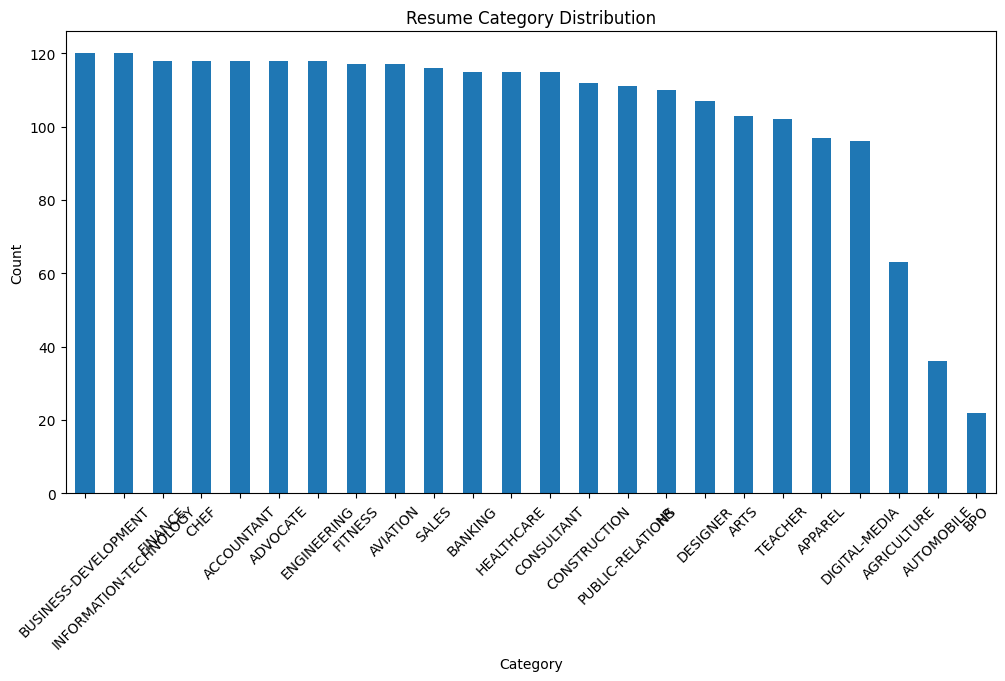

In [10]:
#Resume Categories Analysis
import matplotlib.pyplot as plt

category_counts = df["category"].value_counts()

plt.figure(figsize=(12,6))
category_counts.plot(kind="bar")
plt.title("Resume Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [11]:
#Skill Frequency Extraction
skills = [
    "python","java","sql","excel","machine learning","deep learning",
    "nlp","communication","management","c++","r","tableau",
    "power bi","aws","docker","linux","html","css","javascript"
]

In [12]:
from collections import Counter
import re

skill_counter = Counter()

for text in df["text"]:
    for skill in skills:
        if re.search(r"\b" + re.escape(skill) + r"\b", text):
            skill_counter[skill] += 1

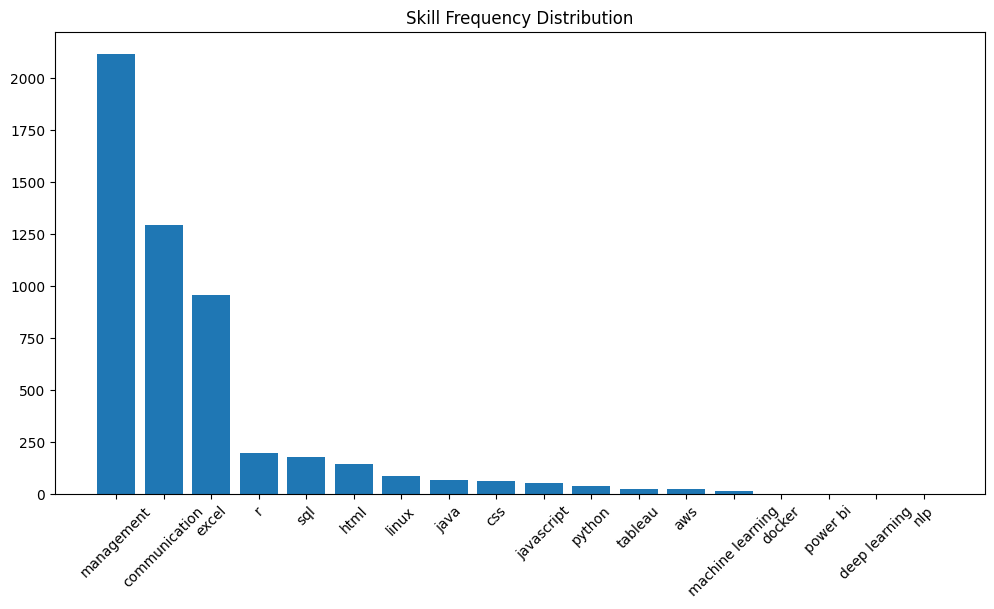

In [13]:
skills_df = pd.DataFrame(skill_counter.items(), columns=["skill","count"])
skills_df = skills_df.sort_values("count", ascending=False)

plt.figure(figsize=(12,6))
plt.bar(skills_df["skill"], skills_df["count"])
plt.xticks(rotation=45)
plt.title("Skill Frequency Distribution")
plt.show()

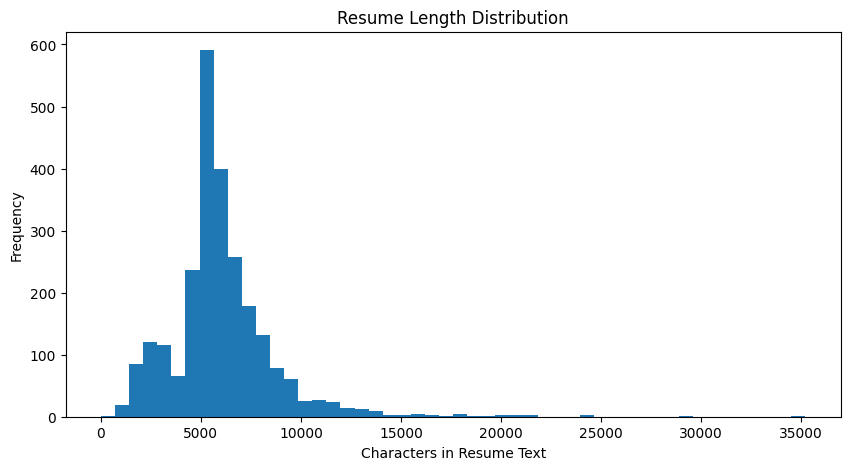

In [14]:
#Resume Length Analysis
plt.figure(figsize=(10,5))
plt.hist(df["length"], bins=50)
plt.title("Resume Length Distribution")
plt.xlabel("Characters in Resume Text")
plt.ylabel("Frequency")
plt.show()

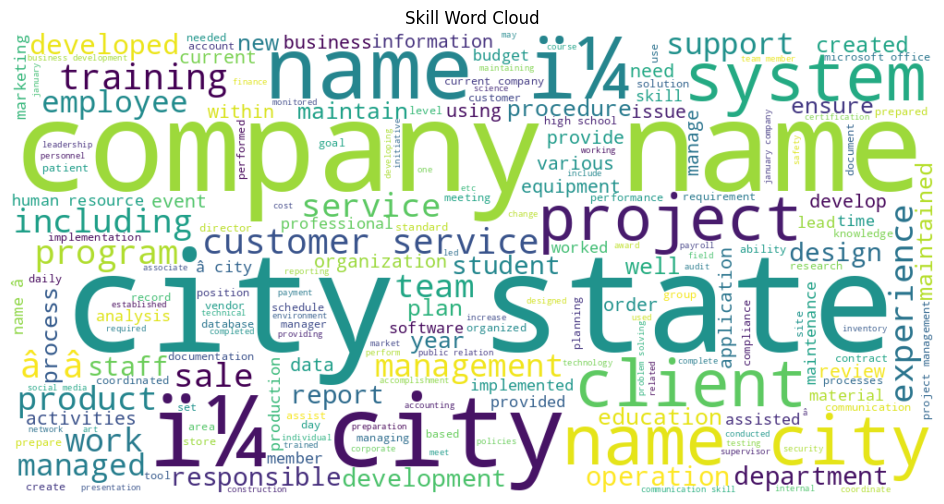

In [15]:
#Skill Word Cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join(df["text"])

wc = WordCloud(width=1000, height=500, background_color="white").generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Skill Word Cloud")
plt.show()

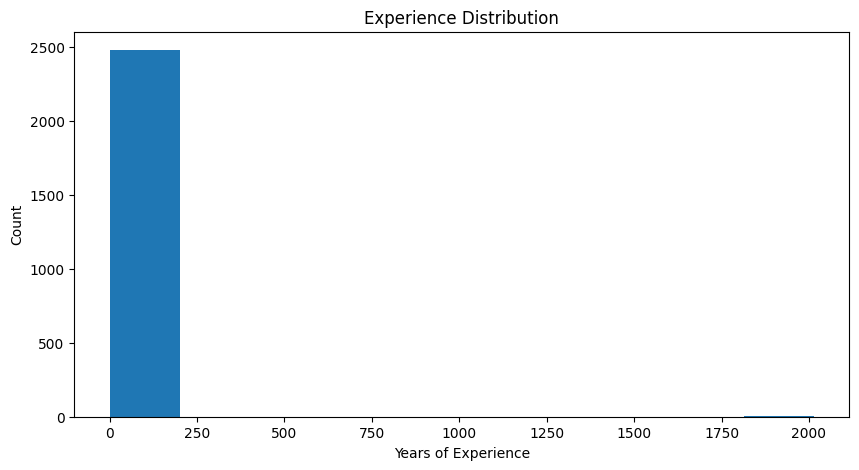

In [16]:
#Experience Distribution
def extract_experience(text):
    match = re.findall(r"(\d+)\+?\s*(?:years|year)", text)
    if match:
        return max([int(x) for x in match])
    return 0
df["experience"] = df["text"].apply(extract_experience)

plt.figure(figsize=(10,5))
plt.hist(df["experience"], bins=10)
plt.title("Experience Distribution")
plt.xlabel("Years of Experience")
plt.ylabel("Count")
plt.show()

**Task 2: Information Extraction Engine**

Extract:

Skills


Experience

Education

Projects

Certifications


In [17]:
import re

In [18]:
SKILLS = [
    "python","java","c++","c","sql","excel","machine learning",
    "deep learning","nlp","data science","tensorflow","pytorch",
    "aws","docker","linux","html","css","javascript","power bi",
    "tableau","communication","management"
]

In [19]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text

In [20]:
#Skill Extraction
def extract_skills(text):
    text = clean_text(text)
    found_skills = []

    for skill in SKILLS:
        if re.search(r'\b' + re.escape(skill) + r'\b', text):
            found_skills.append(skill)

    return list(set(found_skills))

In [21]:
#Experience Extraction
def extract_experience(text):
    text = text.lower()

    patterns = [
        r'(\d+)\+?\s*years? of experience',
        r'experience.*?(\d+)\+?\s*years?',
        r'(\d+)\+?\s*years? experience'
    ]

    years = []

    for pattern in patterns:
        matches = re.findall(pattern, text)
        for m in matches:
            years.append(int(m))

    return max(years) if years else 0

In [22]:
#Education Extraction
def extract_education(text):
    text = text.lower()

    education_keywords = [
        "btech","b.tech","mtech","m.tech","bachelor","master",
        "bsc","msc","bca","mca","phd","b.e","m.e","degree"
    ]

    found = []

    for edu in education_keywords:
        if edu in text:
            found.append(edu)

    return list(set(found))

In [23]:
#Projects Extraction
def extract_projects(text):
    text = text.lower()

    if "project" in text:
        return "mentioned"
    return "not found"

In [24]:
#Certifications Extraction
def extract_certifications(text):
    text = text.lower()

    cert_keywords = [
        "certification","certified","coursera","udemy",
        "edx","nptel","oracle","aws certified","google certified"
    ]

    found = []

    for cert in cert_keywords:
        if cert in text:
            found.append(cert)

    return list(set(found))

In [25]:
df["skills"] = df["text"].apply(extract_skills)
df["experience"] = df["text"].apply(extract_experience)
df["education"] = df["text"].apply(extract_education)
df["projects"] = df["text"].apply(extract_projects)
df["certifications"] = df["text"].apply(extract_certifications)

In [26]:
from collections import Counter

all_skills = sum(df["skills"], [])
skill_counts = Counter(all_skills)

skill_counts.most_common(10)

[('management', 2116),
 ('communication', 1294),
 ('excel', 959),
 ('c', 346),
 ('sql', 178),
 ('html', 143),
 ('linux', 87),
 ('java', 67),
 ('css', 64),
 ('javascript', 55)]

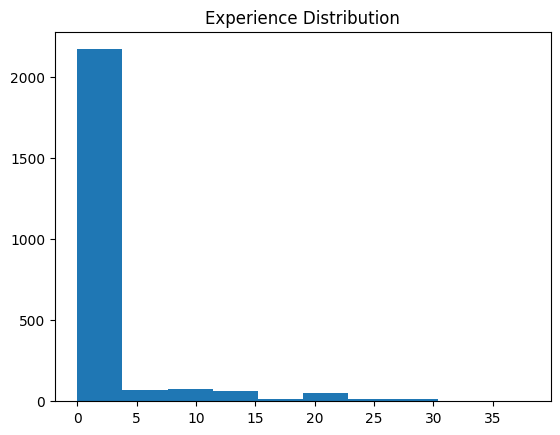

In [27]:
import matplotlib.pyplot as plt

plt.hist(df["experience"], bins=10)
plt.title("Experience Distribution")
plt.show()

**Task 3: Candidate Similarity Engine**

Input:

Job Description

Calculate:

Skill Match %

Experience Match %

Project Match %


In [28]:
job_description = """
Looking for a Python Developer with experience in machine learning, SQL, and data analysis.
Must have 2-5 years of experience.
Projects in NLP or ML are preferred.
"""

In [29]:
def extract_jd_skills(text):
    return extract_skills(text)

def extract_jd_experience(text):
    match = re.findall(r'(\d+)\s*-\s*(\d+)\s*years', text)
    if match:
        return int(match[0][0]), int(match[0][1])

    match = re.findall(r'(\d+)\+?\s*years', text)
    if match:
        return int(match[0]), int(match[0])

    return 0, 100

In [30]:
#Skill Match %
def skill_match(resume_skills, jd_skills):
    if not jd_skills:
        return 0

    match = len(set(resume_skills) & set(jd_skills))
    return round((match / len(jd_skills)) * 100, 2)

In [31]:
#Experience Match %
def experience_match(exp, min_exp, max_exp):
    if exp < min_exp:
        return 0
    elif exp > max_exp:
        return 100
    else:
        return 100

In [32]:
#Project Match %
def project_match(project_text, jd_text):
    keywords = ["ml", "machine learning", "nlp", "data science", "ai"]

    score = 0
    for k in keywords:
        if k in project_text.lower() and k in jd_text.lower():
            score += 1

    return round((score / len(keywords)) * 100, 2)

In [33]:
#Compute Candidate Score
def compute_score(row, jd_text):

    jd_skills = extract_jd_skills(jd_text)
    min_exp, max_exp = extract_jd_experience(jd_text)

    skill_score = skill_match(row["skills"], jd_skills)
    exp_score = experience_match(row["experience"], min_exp, max_exp)
    proj_score = project_match(row["projects"], jd_text)

    final_score = (
        0.5 * skill_score +
        0.3 * exp_score +
        0.2 * proj_score
    )

    return pd.Series([skill_score, exp_score, proj_score, final_score])

In [34]:
df[["skill_score", "exp_score", "project_score", "final_score"]] = df.apply(
    compute_score,
    axis=1,
    args=(job_description,)
)

In [35]:
df_sorted = df.sort_values("final_score", ascending=False)
df_sorted[["category", "skills", "experience", "final_score"]].head(10)

,category,skills,experience,final_score
564,CONSULTANT,"[data science, javascript, c, java, sql, pytho...",6,67.5
871,AGRICULTURE,"[data science, aws, java, sql, python, managem...",20,55.0
529,CONSULTANT,"[excel, tableau, sql, management, machine lear...",2,55.0
2110,ENGINEERING,"[communication, python, linux, sql]",10,55.0
894,AGRICULTURE,"[html, javascript, c, css, tableau, sql, commu...",5,55.0
2034,ENGINEERING,"[linux, sql, communication, python, management]",14,55.0
1549,INFORMATION-TECHNOLOGY,"[management, sql]",10,42.5
2030,ENGINEERING,"[management, c, sql]",3,42.5
453,SALES,"[communication, management, sql]",4,42.5
1534,INFORMATION-TECHNOLOGY,"[javascript, linux, c, css, java, sql, managem...",10,42.5


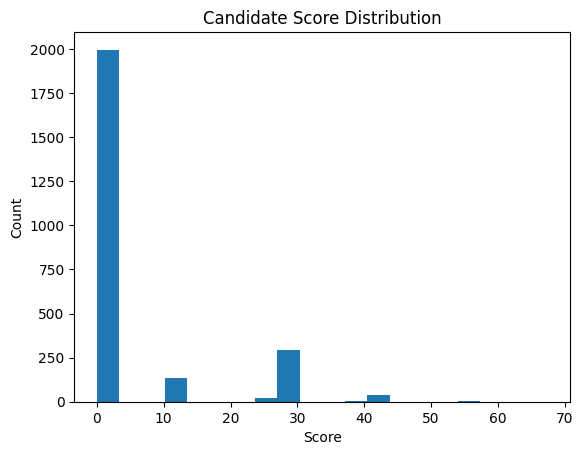

In [36]:
#Score Distribution
import matplotlib.pyplot as plt

plt.hist(df["final_score"], bins=20)
plt.title("Candidate Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

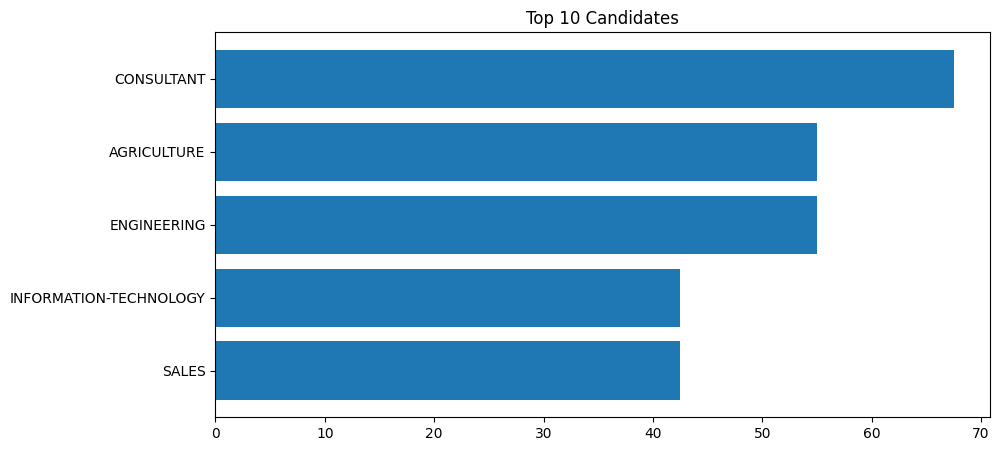

In [37]:
#Top Candidates
top = df_sorted.head(10)

plt.figure(figsize=(10,5))
plt.barh(top["category"], top["final_score"])
plt.title("Top 10 Candidates")
plt.gca().invert_yaxis()
plt.show()

**Task 4: Self-Attention Model**

Build:

Embedding

↓

MultiHeadAttention

↓

Classification


In [38]:
df["text"]   # resume text
df["category"]  # label

,category
0,DESIGNER
1,DESIGNER
2,DESIGNER
3,DESIGNER
4,DESIGNER
...,...
2479,ARTS
2480,ARTS
2481,ARTS
2482,ARTS


In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label"] = le.fit_transform(df["category"])
num_classes = len(le.classes_)

In [40]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 20000
MAX_LEN = 300

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df["text"])

sequences = tokenizer.texts_to_sequences(df["text"])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding="post")

y = df["label"].values

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
import tensorflow as tf
from tensorflow.keras import layers

In [43]:
inputs = layers.Input(shape=(MAX_LEN,))

# Embedding
x = layers.Embedding(MAX_VOCAB, 128)(inputs)

# Self-Attention Block
attn = layers.MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
x = layers.Add()([x, attn])
x = layers.LayerNormalization()(x)

# Feed Forward Network
ff = layers.Dense(128, activation="relu")(x)
ff = layers.Dense(128)(ff)

x = layers.Add()([x, ff])
x = layers.LayerNormalization()(x)

# Pooling
x = layers.GlobalAveragePooling1D()(x)

# Classification Head
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

In [44]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 128)  │  2,560,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 300, 128)  │     66,048 │ embedding[0][0],  │
│ (MultiHeadAttentio… │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 300, 128)  │          0 │ embedding[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 300, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 300, 128)  │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 300, 128)  │     16,512 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 300, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 300, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 24)        │      3,096 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,679,192 (10.22 MB)

 Trainable params: 2,679,192 (10.22 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=32
)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - accuracy: 0.1243 - loss: 3.0362 - val_accuracy: 0.2173 - val_loss: 2.7458
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3387 - loss: 2.2861 - val_accuracy: 0.3602 - val_loss: 2.3454
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5702 - loss: 1.5176 - val_accuracy: 0.4286 - val_loss: 2.1482
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7564 - loss: 0.8477 - val_accuracy: 0.4266 - val_loss: 2.2708
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8968 - loss: 0.3838 - val_accuracy: 0.4427 - val_loss: 2.6821


In [46]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4427 - loss: 2.6821
Test Accuracy: 0.44265592098236084


In [47]:
def predict_resume(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post")

    pred = model.predict(padded)
    label = le.inverse_transform([pred.argmax()])[0]

    return label

**Task 5: Positional Encoding**

Implement manually.

Students must prove:

Resume order affects understanding.


In [48]:
import numpy as np

def positional_encoding(max_len, d_model):
    PE = np.zeros((max_len, d_model))

    for pos in range(max_len):
        for i in range(0, d_model, 2):
            angle = pos / np.power(10000, (2 * (i//2)) / d_model)

            PE[pos, i] = np.sin(angle)
            if i + 1 < d_model:
                PE[pos, i + 1] = np.cos(angle)

    return PE

In [49]:
max_len = 50   # resume sentences or tokens
d_model = 16

PE = positional_encoding(max_len, d_model)

print(PE.shape)

(50, 16)


In [50]:
embeddings = np.random.rand(max_len, d_model)

encoded = embeddings + PE

In [51]:
resume_1 = "Python developer with ML experience"

In [52]:
resume_2 = "ML experience with Python developer"

In [53]:
def dummy_embedding(text, d_model=16):
    np.random.seed(len(text))  # deterministic fake embedding
    return np.random.rand(len(text.split()), d_model)

In [54]:
def encode(text):
    emb = dummy_embedding(text)
    pe = positional_encoding(len(emb), emb.shape[1])
    return emb + pe

In [55]:
from numpy.linalg import norm

e1 = encode(resume_1)
e2 = encode(resume_2)

similarity = np.sum(e1 * e2) / (norm(e1) * norm(e2))

print("Similarity:", similarity)

Similarity: 1.0


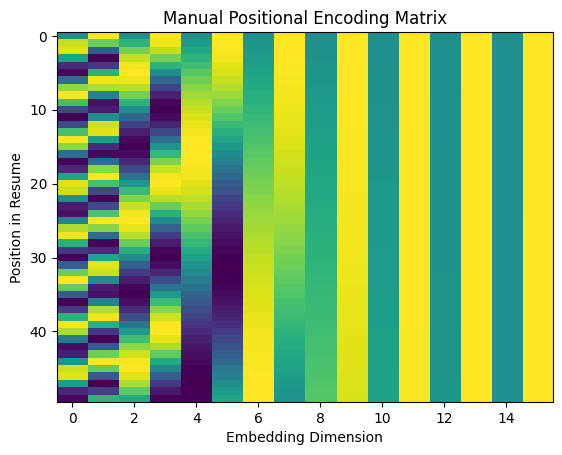

In [56]:
import matplotlib.pyplot as plt

plt.imshow(PE, aspect='auto')
plt.title("Manual Positional Encoding Matrix")
plt.xlabel("Embedding Dimension")
plt.ylabel("Position in Resume")
plt.show()

**Task 6: Resume Ranking Engine**

Rank:

Top 10 Candidates
based on similarity score.


In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

resume_vectors = vectorizer.fit_transform(df["text"])

In [58]:
job_description = """
Python developer with experience in Machine Learning, Deep Learning,
NLP, and data analysis. Must know sklearn, pandas, and TensorFlow.
"""

job_vector = vectorizer.transform([job_description])

In [59]:
from sklearn.metrics.pairwise import cosine_similarity

scores = cosine_similarity(job_vector, resume_vectors).flatten()

df["similarity"] = scores

In [60]:
top_10 = df.sort_values(by="similarity", ascending=False).head(10)

top_10[["path", "similarity"]]

,path,similarity
871,/kaggle/input/resume-dataset/data/data/AGRICUL...,0.213478
2290,/kaggle/input/resume-dataset/data/data/BANKING...,0.205220
2473,/kaggle/input/resume-dataset/data/data/ARTS/12...,0.204070
2124,/kaggle/input/resume-dataset/data/data/ENGINEE...,0.188042
67,/kaggle/input/resume-dataset/data/data/DESIGNE...,0.187641
564,/kaggle/input/resume-dataset/data/data/CONSULT...,0.155486
996,/kaggle/input/resume-dataset/data/data/TEACHER...,0.151465
946,/kaggle/input/resume-dataset/data/data/TEACHER...,0.145238
482,/kaggle/input/resume-dataset/data/data/AUTOMOB...,0.145103
481,/kaggle/input/resume-dataset/data/data/AUTOMOB...,0.138929


In [61]:
top_10["candidate_rank"] = range(1, 11)

result = top_10[["candidate_rank", "path", "similarity"]]
result

,candidate_rank,path,similarity
871,1,/kaggle/input/resume-dataset/data/data/AGRICUL...,0.213478
2290,2,/kaggle/input/resume-dataset/data/data/BANKING...,0.205220
2473,3,/kaggle/input/resume-dataset/data/data/ARTS/12...,0.204070
2124,4,/kaggle/input/resume-dataset/data/data/ENGINEE...,0.188042
67,5,/kaggle/input/resume-dataset/data/data/DESIGNE...,0.187641
564,6,/kaggle/input/resume-dataset/data/data/CONSULT...,0.155486
996,7,/kaggle/input/resume-dataset/data/data/TEACHER...,0.151465
946,8,/kaggle/input/resume-dataset/data/data/TEACHER...,0.145238
482,9,/kaggle/input/resume-dataset/data/data/AUTOMOB...,0.145103
481,10,/kaggle/input/resume-dataset/data/data/AUTOMOB...,0.138929


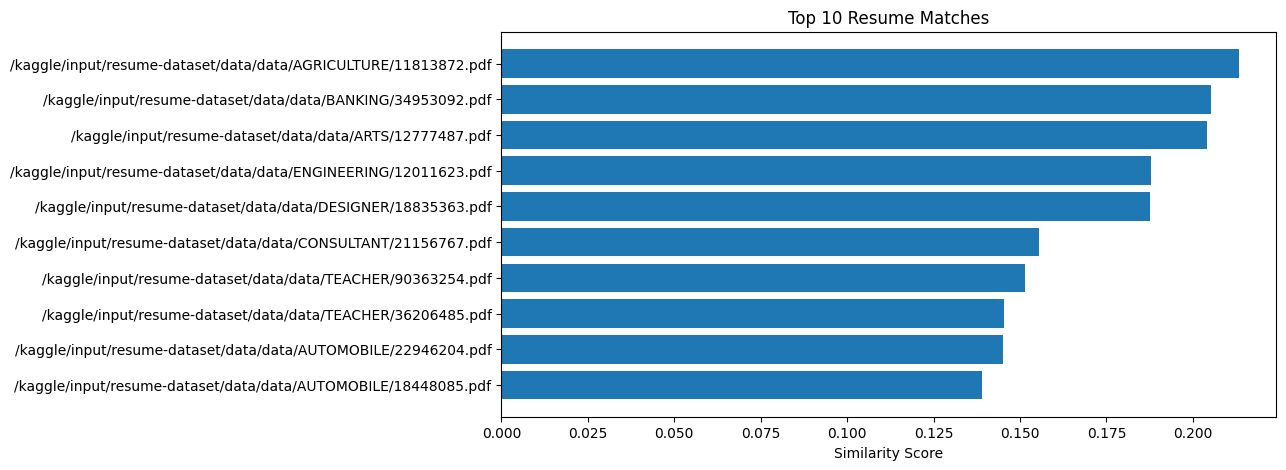

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(top_10["path"].astype(str), top_10["similarity"])
plt.gca().invert_yaxis()
plt.title("Top 10 Resume Matches")
plt.xlabel("Similarity Score")
plt.show()

**Task 7: Explainability Module**

Show:

Why candidate was selected?

Display:

Important skills

Attention scores

Matching evidence


In [63]:
import re

skills_list = [
    "python","java","c++","machine learning","deep learning",
    "nlp","tensorflow","pytorch","sql","pandas","numpy",
    "sklearn","data analysis","excel","aws","docker"
]

def extract_skills(text):
    text = text.lower()
    found = [skill for skill in skills_list if skill in text]
    return set(found)

In [64]:
job_skills = extract_skills(job_description)
df["skills"] = df["text"].apply(extract_skills)

def skill_match_score(candidate_skills):
    if len(job_skills) == 0:
        return 0
    return len(job_skills.intersection(candidate_skills)) / len(job_skills)

df["skill_match"] = df["skills"].apply(skill_match_score)

In [65]:
def extract_evidence(text):
    sentences = text.split(".")
    matched = []

    for s in sentences:
        for skill in job_skills:
            if skill in s.lower():
                matched.append(s.strip())
                break

    return matched[:5]  # top 5 evidence lines

In [66]:
df["evidence"] = df["text"].apply(extract_evidence)

In [67]:
feature_names = vectorizer.get_feature_names_out()

def top_attention_words(vector, top_n=10):
    indices = vector.toarray().flatten().argsort()[-top_n:]
    return [feature_names[i] for i in indices]

In [68]:
top_candidate = df.sort_values("similarity", ascending=False).iloc[0]

top_vector = vectorizer.transform([top_candidate["text"]])

attention_words = top_attention_words(top_vector)

In [71]:
print("--- Candidate Selected:---")
print(top_candidate["path"])

print("\n--- Similarity Score:---", top_candidate["similarity"])

print("\n--- Important Skills Match:---")
print(top_candidate["skills"])

print("\n--- Job Required Skills:---")
print(job_skills)

print("\n--- Skill Match %:---", top_candidate["skill_match"] * 100)

print("\n--- Matching Evidence:---")
for e in top_candidate["evidence"]:
    print("-", e)

print("\n--- Important Keywords (Attention Proxy):---")
print(attention_words)

--- Candidate Selected:---
/kaggle/input/resume-dataset/data/data/AGRICULTURE/11813872.pdf

--- Similarity Score:--- 0.21347833144341719

--- Important Skills Match:---
{'aws', 'pandas', 'java', 'sql', 'python'}

--- Job Required Skills:---
{'deep learning', 'nlp', 'data analysis', 'pandas', 'sklearn', 'python', 'machine learning', 'tensorflow'}

--- Skill Match %:--- 25.0

--- Matching Evidence:---
- deep expertise in financial instruments modeling
including complex derivative products
portfolio and investment management
deep expertise in oracle exadata, amazon redshift,
sql,python,java,apache ignite, aws and related technologies
- pandas, matplotlib
etc
- developed an automated process
to update meta-data in yaml format using python to improve efficiency and time to market
- hospital management system
shares management system
asset management system
payroll and personnel information system
accounting management system
vehicle management system
inventory management system (ims)
educat

In [73]:
import pickle
import tensorflow as tf


model.save("resume_model.h5")

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Saved all files!")

Saved all files!


In [74]:
from google.colab import files

files.download("resume_model.h5")
files.download("tokenizer.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>